# Model Training

## 1 Import Data and Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("data/data.csv")

In [3]:
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [4]:
df.describe()

,Age,Protein1,Protein2,Protein3,Protein4
count,334.000000,334.000000,334.000000,334.000000,334.000000
mean,58.886228,-0.029991,0.946896,-0.090204,0.009819
std,12.961212,0.563588,0.911637,0.585175,0.629055
min,29.000000,-2.340900,-0.978730,-1.627400,-2.025500
25%,49.000000,-0.358888,0.362173,-0.513748,-0.377090
50%,58.000000,0.006129,0.992805,-0.173180,0.041768
75%,68.000000,0.343598,1.627900,0.278353,0.425630
max,90.000000,1.593600,3.402200,2.193400,1.629900


In [5]:
df = df.copy()

# Handle missing values in target variable
df = df.dropna(subset=['Patient_Status'])
print(f"Rows after removing missing Patient_Status: {len(df)}")

Rows after removing missing Patient_Status: 321


In [6]:
# convert object column in datetime format
df['Date_of_Surgery'] = pd.to_datetime(df['Date_of_Surgery'], errors='coerce')
df['Date_of_Last_Visit'] = pd.to_datetime(df['Date_of_Last_Visit'], errors='coerce')
 

In [7]:
# Create Survived_days days feature
df['Survived_days'] = (df['Date_of_Last_Visit']- df['Date_of_Surgery']).dt.days

In [8]:
df["Survived_days"] = df["Survived_days"].fillna(df["Survived_days"].median())

In [9]:
df = df.drop(columns=["Date_of_Surgery", "Date_of_Last_Visit"])

In [10]:
df.isnull().sum()

Age               0
Gender            0
Protein1          0
Protein2          0
Protein3          0
Protein4          0
Tumour_Stage      0
Histology         0
ER status         0
PR status         0
HER2 status       0
Surgery_type      0
Patient_Status    0
Survived_days     0
dtype: int64

In [11]:
df = df.drop(columns=["ER status","PR status"])

In [12]:
df.shape

(321, 12)

In [13]:
stage_map = {
    'I': 1,
    'II': 2,
    'III': 3
}
df['Tumour_Stage_Encoded'] = df['Tumour_Stage'].map(stage_map)

print(df[['Tumour_Stage', 'Tumour_Stage_Encoded']].head(10))

   Tumour_Stage  Tumour_Stage_Encoded
0            II                     2
1            II                     2
2            II                     2
3             I                     1
4            II                     2
5           III                     3
6            II                     2
7           III                     3
8            II                     2
10           II                     2


In [14]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
ohe_transformed = ohe.fit_transform(df[['Surgery_type', 'Histology']])
df = pd.concat([df.drop(columns=['Surgery_type', 'Histology']), ohe_transformed], axis=1)

In [15]:
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,HER2 status,Patient_Status,Survived_days,Tumour_Stage_Encoded,Surgery_type_Lumpectomy,Surgery_type_Modified Radical Mastectomy,Surgery_type_Other,Surgery_type_Simple Mastectomy,Histology_Infiltrating Ductal Carcinoma,Histology_Infiltrating Lobular Carcinoma,Histology_Mucinous Carcinoma
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Negative,Alive,98.0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Negative,Dead,274.0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Negative,Alive,593.0,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Negative,Alive,620.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Positive,Alive,24.0,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
print(df.columns)

Index(['Age', 'Gender', 'Protein1', 'Protein2', 'Protein3', 'Protein4',
       'Tumour_Stage', 'HER2 status', 'Patient_Status', 'Survived_days',
       'Tumour_Stage_Encoded', 'Surgery_type_Lumpectomy',
       'Surgery_type_Modified Radical Mastectomy', 'Surgery_type_Other',
       'Surgery_type_Simple Mastectomy',
       'Histology_Infiltrating Ductal Carcinoma',
       'Histology_Infiltrating Lobular Carcinoma',
       'Histology_Mucinous Carcinoma'],
      dtype='object')


In [17]:
df['Patient_Status'] = df['Patient_Status'].map({'Alive': 1, 'Dead': 0})
df['HER2 status'] = df['HER2 status'].map({'Positive': 1, 'Negative': 0})
df['Gender'] = df['Gender'].map({'FEMALE': 0, 'MALE': 1})

In [18]:
df=df.drop(columns=["Tumour_Stage"],axis=1)

In [19]:
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,HER2 status,Patient_Status,Survived_days,Tumour_Stage_Encoded,Surgery_type_Lumpectomy,Surgery_type_Modified Radical Mastectomy,Surgery_type_Other,Surgery_type_Simple Mastectomy,Histology_Infiltrating Ductal Carcinoma,Histology_Infiltrating Lobular Carcinoma,Histology_Mucinous Carcinoma
0,42,0,0.95256,2.15000,0.007972,-0.048340,0,1,98.0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,54,0,0.00000,1.38020,-0.498030,-0.507320,0,0,274.0,2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,63,0,-0.52303,1.76400,-0.370190,0.010815,0,1,593.0,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,78,0,-0.87618,0.12943,-0.370380,0.132190,0,1,620.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,42,0,0.22611,1.74910,-0.543970,-0.390210,1,1,24.0,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 321 entries, 0 to 333
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       321 non-null    int64  
 1   Gender                                    321 non-null    int64  
 2   Protein1                                  321 non-null    float64
 3   Protein2                                  321 non-null    float64
 4   Protein3                                  321 non-null    float64
 5   Protein4                                  321 non-null    float64
 6   HER2 status                               321 non-null    int64  
 7   Patient_Status                            321 non-null    int64  
 8   Survived_days                             321 non-null    float64
 9   Tumour_Stage_Encoded                      321 non-null    int64  
 10  Surgery_type_Lumpectomy                   3

In [21]:
df['Patient_Status'].value_counts()

Patient_Status
1    255
0     66
Name: count, dtype: int64

# Split data into train and test set

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# Separate features (X) and target (y)
X = df.drop(columns=['Patient_Status','Survived_days'])
y = df['Patient_Status']

In [24]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42,stratify=y)

print(f"Total data: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Total data: 321
Training set size: 256 (79.8%)
Testing set size: 65 (20.2%)


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

scale_cols = ['Age', 'Protein1', 'Protein2', 'Protein3', 'Protein4'] 

scaler = ColumnTransformer([
    ('num_scale', StandardScaler(), scale_cols)
], remainder='passthrough')

X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(
    X_scaled,
    y_train
)

## train multiple classification models

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, recall_score,precision_score,f1_score,roc_auc_score,roc_curve,confusion_matrix

In [28]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(class_weight='balanced',kernel='rbf', probability=True, random_state=42), # Added comma here
    'XGBOOST': XGBClassifier(class_weight='balanced',random_state=42),

    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    'Naive Bayes': GaussianNB(),
}

trained_models = {}
model_scores = {}

print("Training Models...")

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(x_train_balanced, y_train_balanced) 
    trained_models[name] = model
    
    # Predict
    y_pred_train = model.predict(x_train_balanced)
    y_pred_test = model.predict(X_test_scaled)

    # Metrics calculation
    train_accuracy = accuracy_score(y_train_balanced, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test) # Result variable 'f1'
    report = classification_report(y_test, y_pred_test)
    matrix = confusion_matrix(y_test, y_pred_test)
    roc_auc = roc_auc_score(y_test, y_pred_test)

    # Store results
    model_scores[name] = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,       # Fix: Use variable 'f1'
        'report': report,
        'matrix' : matrix,
        'roc_auc' : roc_auc
    }

    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy:  {test_accuracy:.4f}")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1 Score:       {f1:.4f}") # Fix: Use variable 'f1'
    print(f"Report:\n{report}")
    print(f"matrix : {matrix}")
    print(f"ROC-AUC : {roc_auc}")
    

# Best model selection
best_model_name = max(model_scores, key=lambda x: model_scores[x]['test_accuracy'])

print("\n" + "=" * 40)
print(f"BEST MODEL: {best_model_name}")
print(f"TEST ACCURACY: {model_scores[best_model_name]['test_accuracy']:.4f}")
print("=" * 40)

Training Models...

Training Logistic Regression...
Train Accuracy: 0.6773
Test Accuracy:  0.4923
Precision:      0.7714
Recall:         0.5192
F1 Score:       0.6207
Report:
              precision    recall  f1-score   support

           0       0.17      0.38      0.23        13
           1       0.77      0.52      0.62        52

    accuracy                           0.49        65
   macro avg       0.47      0.45      0.43        65
weighted avg       0.65      0.49      0.54        65

matrix : [[ 5  8]
 [25 27]]
ROC-AUC : 0.45192307692307687

Training Random Forest...
Train Accuracy: 0.9532
Test Accuracy:  0.7385
Precision:      0.8302
Recall:         0.8462
F1 Score:       0.8381
Report:
              precision    recall  f1-score   support

           0       0.33      0.31      0.32        13
           1       0.83      0.85      0.84        52

    accuracy                           0.74        65
   macro avg       0.58      0.58      0.58        65
weighted avg      

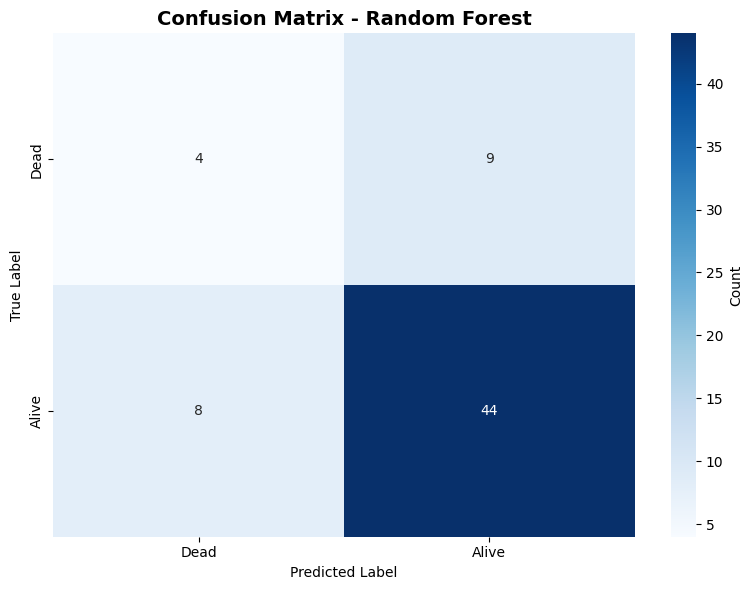

In [29]:
best_model = trained_models[best_model_name]
best_model_preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, best_model_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dead', 'Alive'],
            yticklabels=['Dead', 'Alive'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

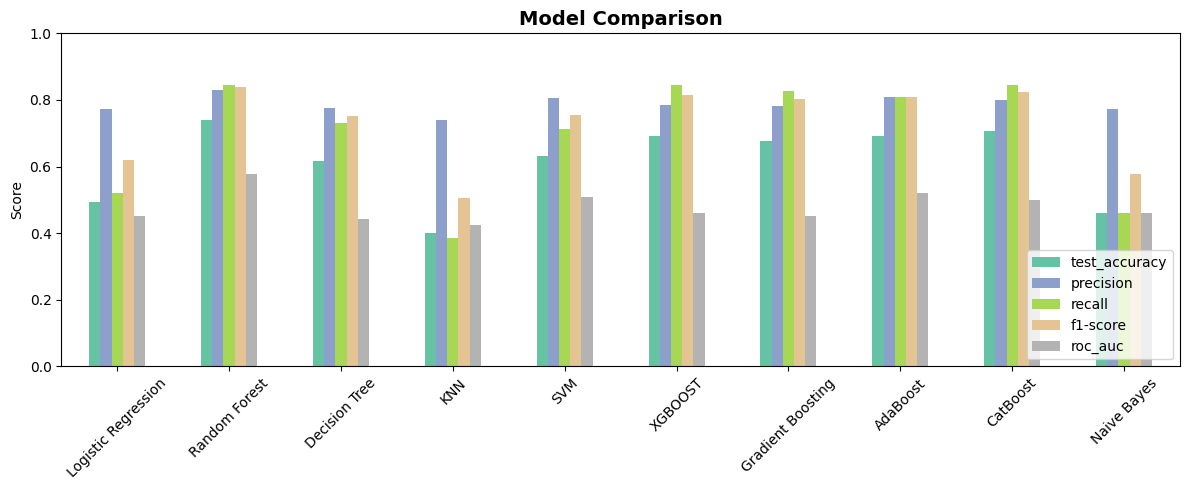

In [30]:
scores_df = pd.DataFrame(model_scores).T[['test_accuracy', 'precision', 'recall', 'f1-score', 'roc_auc']]

scores_df.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

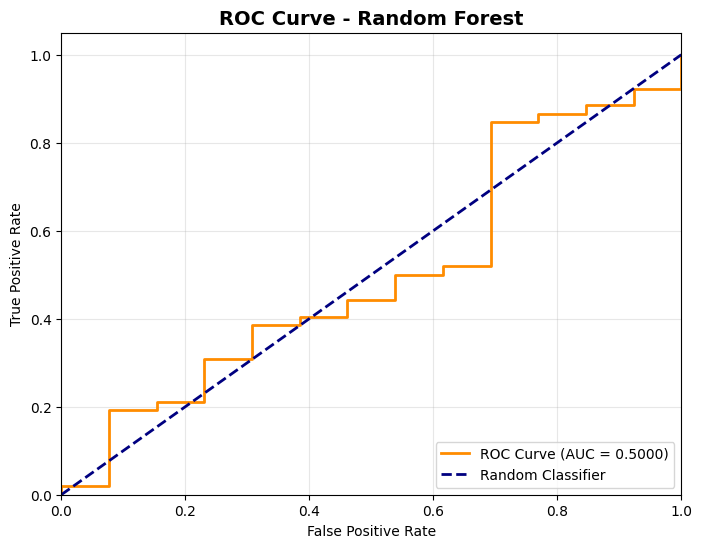

In [31]:
# probability for positive class — use best model, not the dict

y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Make prediction on New samples

In [32]:
# Example: Create a new patient sample and make a prediction
new_patient = pd.DataFrame({
    'Age': [55],
    'Gender': ['FEMALE'],
    'Protein1': [0.5],
    'Protein2': [1.5],
    'Protein3': [-0.3],
    'Protein4': [0.2],
    'Tumour_Stage': ['II'],
    'Histology': ['Infiltrating Ductal Carcinoma'],
    'HER2 status': ['Negative'],
    'Surgery_type': ['Lumpectomy'],
})

print("=" * 60)
print("PREDICTING SURVIVAL FOR A NEW PATIENT")
print("=" * 60)

print("\nNew Patient Data:")
print(new_patient)


PREDICTING SURVIVAL FOR A NEW PATIENT

New Patient Data:
   Age  Gender  Protein1  Protein2  Protein3  Protein4 Tumour_Stage  \
0   55  FEMALE       0.5       1.5      -0.3       0.2           II   

                       Histology HER2 status Surgery_type  
0  Infiltrating Ductal Carcinoma    Negative   Lumpectomy  


In [33]:
# Step 1: Copy
new_patient_encoded = new_patient.copy()

In [34]:
# Step 2: Ordinal encode Tumour_Stage
stage_map = {'I': 1, 'II': 2, 'III': 3}
new_patient_encoded['Tumour_Stage_Encoded'] = new_patient_encoded['Tumour_Stage'].map(stage_map)
new_patient_encoded = new_patient_encoded.drop(columns=['Tumour_Stage'])

In [35]:

# Step 3: OHE for Surgery_type and Histology (same ohe object from training)
ohe_cols = ohe.transform(new_patient_encoded[['Surgery_type', 'Histology']])
new_patient_encoded = pd.concat(
    [new_patient_encoded.drop(columns=['Surgery_type', 'Histology']), ohe_cols], axis=1
)

In [36]:
# Step 4: Binary encode
new_patient_encoded['HER2 status'] = new_patient_encoded['HER2 status'].map({'Positive': 1, 'Negative': 0})
new_patient_encoded['Gender'] = new_patient_encoded['Gender'].map({'FEMALE': 0, 'MALE': 1})

In [37]:
# Step 5: Scale (same scaler from training)
new_patient_scaled = scaler.transform(new_patient_encoded)

In [38]:
# Step 6: Predict
prediction = best_model.predict(new_patient_scaled)[0]
prediction_proba = best_model.predict_proba(new_patient_scaled)[0]

In [39]:
# Step 7: Display Result
print("=" * 50)
print("        PATIENT SURVIVAL PREDICTION")
print("=" * 50)
print(f"  Age              : 55")
print(f"  Gender           : Female")
print(f"  Tumour Stage     : II")
print(f"  Histology        : Infiltrating Ductal Carcinoma")
print(f"  Surgery Type     : Lumpectomy")
print(f"  HER2 Status      : Negative")
print("-" * 50)
print(f"  Predicted Status : {'Alive' if prediction == 1 else 'Dead ✗'}")
print(f"  Probability Alive: {prediction_proba[1]:.2%}")
print(f"  Probability Dead : {prediction_proba[0]:.2%}")
print("=" * 50)

        PATIENT SURVIVAL PREDICTION
  Age              : 55
  Gender           : Female
  Tumour Stage     : II
  Histology        : Infiltrating Ductal Carcinoma
  Surgery Type     : Lumpectomy
  HER2 Status      : Negative
--------------------------------------------------
  Predicted Status : Alive
  Probability Alive: 74.59%
  Probability Dead : 25.41%


In [40]:
y_pred_best = best_model.predict(X_test_scaled)

pred_df = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred_best,
    'Difference': y_test.values - y_pred_best
})
pred_df

,Actual Value,Predicted Value,Difference
0,1,1,0
1,1,0,1
2,0,0,0
3,1,1,0
4,1,1,0
...,...,...,...
60,1,0,1
61,1,1,0
62,1,1,0
63,1,1,0


In [41]:
total = len(pred_df)
correct = (pred_df['Difference'] == 0).sum()
incorrect = (pred_df['Difference'] != 0).sum()

print("=" * 40)
print("      PREDICTION SUMMARY")
print("=" * 40)
print(f"  Total Patients        : {total}")
print(f"  Correct Predictions   : {correct} ({correct/total*100:.1f}%)")
print(f"  Incorrect Predictions : {incorrect} ({incorrect/total*100:.1f}%)")
print("-" * 40)
print(f"  False Positives (Alive → Dead) : {(pred_df['Difference'] == 1).sum()}")
print(f"  False Negatives (Dead → Alive) : {(pred_df['Difference'] == -1).sum()}")
print("=" * 40)

      PREDICTION SUMMARY
  Total Patients        : 65
  Correct Predictions   : 48 (73.8%)
  Incorrect Predictions : 17 (26.2%)
----------------------------------------
  False Positives (Alive → Dead) : 8
  False Negatives (Dead → Alive) : 9
